In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split

In [2]:
diabetes = load_diabetes()
df = pd.DataFrame(diabetes.data,columns = diabetes.feature_names)

In [5]:
df.corr()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
age,1.000000,0.173737,0.185085,0.335428,0.260061,0.219243,-0.075181,0.203841,0.270774,0.301731
sex,0.173737,1.000000,0.088161,0.241010,0.035277,0.142637,-0.379090,0.332115,0.149916,0.208133
bmi,0.185085,0.088161,1.000000,0.395411,0.249777,0.261170,-0.366811,0.413807,0.446157,0.388680
bp,0.335428,0.241010,0.395411,1.000000,0.242464,0.185548,-0.178762,0.257650,0.393480,0.390430
s1,0.260061,0.035277,0.249777,0.242464,1.000000,0.896663,0.051519,0.542207,0.515503,0.325717
s2,0.219243,0.142637,0.261170,0.185548,0.896663,1.000000,-0.196455,0.659817,0.318357,0.290600
s3,-0.075181,-0.379090,-0.366811,-0.178762,0.051519,-0.196455,1.000000,-0.738493,-0.398577,-0.273697
s4,0.203841,0.332115,0.413807,0.257650,0.542207,0.659817,-0.738493,1.000000,0.617859,0.417212
s5,0.270774,0.149916,0.446157,0.393480,0.515503,0.318357,-0.398577,0.617859,1.000000,0.464669
s6,0.301731,0.208133,0.388680,0.390430,0.325717,0.290600,-0.273697,0.417212,0.464669,1.000000


In [6]:
x = df[["bmi","bp"]]
y = diabetes.target

In [7]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = .2,random_state = 42)

In [10]:
X_b = np.c_[np.ones((x_train.shape[0], 1)), x_train.values]

In [11]:
y = y_train.reshape(-1, 1) if isinstance(y_train, np.ndarray) else y_train.to_numpy().reshape(-1, 1)

In [12]:
theta = np.zeros((X_b.shape[1], 1))

In [13]:
alpha = 0.1
epochs = 1000

In [14]:
for epoch in range(epochs):
    predictions = X_b @ theta
    error = predictions - y
    gradients = (2 / len(X_b)) * X_b.T @ error
    theta = theta - alpha * gradients


In [15]:
print("Learned weights (θ):", theta.ravel())

Learned weights (θ): [152.86945795 338.59120663 239.57565799]


### PLotting

In [17]:
import matplotlib.pyplot as plt

# Use just the BMI feature for 2D plotting
X_bmi = x_train['bmi'].to_numpy().reshape(-1, 1)
y_train = y_train.reshape(-1, 1)  # Ensure y is 2D

# Add bias (intercept term)
X_b_bmi = np.concatenate((np.ones((X_bmi.shape[0], 1)), X_bmi), axis=1)

# Use the learned theta (assume you already have this from training)
y_pred = X_b_bmi @ theta[:2]  # Only take weights for bias and bmi


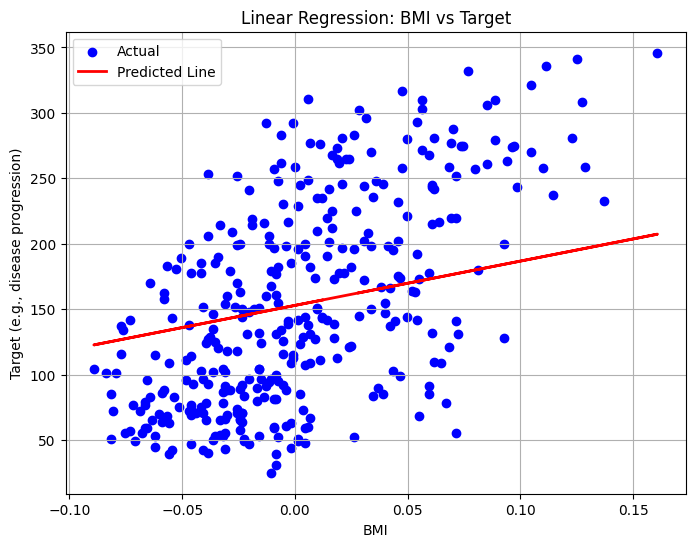

In [18]:
plt.figure(figsize=(8, 6))

# Actual data points
plt.scatter(X_bmi, y_train, color='blue', label='Actual')

# Predicted regression line
plt.plot(X_bmi, y_pred, color='red', linewidth=2, label='Predicted Line')

plt.xlabel('BMI')
plt.ylabel('Target (e.g., disease progression)')
plt.title('Linear Regression: BMI vs Target')
plt.legend()
plt.grid(True)
plt.show()
